In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [46]:
data_types = {
    'Store': 'int16',
    'DayOfWeek': 'int8',
    'Sales': 'int32',
    'Open': 'bool',
    'Promo': 'bool',
    'StateHoliday': 'category',
    'SchoolHoliday': 'int8',
    'StoreType': 'category',
    'Assortment': 'category',
    'CompetitionDistance': 'float32',
    'CompetitionOpenSinceMonth': 'float32',
    'CompetitionOpenSinceYear': 'float32',
    'Promo2': 'bool',
    'Promo2SinceWeek': 'float32',
    'Promo2SinceYear': 'float32',
    'PromoInterval': 'string'}

In [47]:
data = pd.read_csv(
    "../../Data/Preprocessed/merged_training_data.csv",
    parse_dates=['Date'],
    index_col='Date_index',
    encoding="utf-8",
    dtype=data_types)
data.head()

,Store,DayOfWeek,Date,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Date_index,,,,,,,,,,,,,,,,,
2015-07-31,1,5,2015-07-31,5263,True,True,0,1,c,a,1270.0,9.0,2008.0,False,NaN,NaN,<NA>
2015-07-31,2,5,2015-07-31,6064,True,True,0,1,a,a,570.0,11.0,2007.0,True,13.0,2010.0,"Jan,Apr,Jul,Oct"
2015-07-31,3,5,2015-07-31,8314,True,True,0,1,a,a,14130.0,12.0,2006.0,True,14.0,2011.0,"Jan,Apr,Jul,Oct"
2015-07-31,4,5,2015-07-31,13995,True,True,0,1,c,c,620.0,9.0,2009.0,False,NaN,NaN,<NA>
2015-07-31,5,5,2015-07-31,4822,True,True,0,1,a,a,29910.0,4.0,2015.0,False,NaN,NaN,<NA>


## 1- Data Exploration & data cleaning

In [48]:
data.shape

(1017209, 17)

In [49]:
data.dtypes

Store                                 int16
DayOfWeek                              int8
Date                         datetime64[ns]
Sales                                 int32
Open                                   bool
Promo                                  bool
StateHoliday                       category
SchoolHoliday                          int8
StoreType                          category
Assortment                         category
CompetitionDistance                 float32
CompetitionOpenSinceMonth           float32
CompetitionOpenSinceYear            float32
Promo2                                 bool
Promo2SinceWeek                     float32
Promo2SinceYear                     float32
PromoInterval                string[python]
dtype: object

In [50]:
data = data[[
    "Store", "Open", "Date", "DayOfWeek",
    "CompetitionDistance",
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear",
    "StateHoliday", "SchoolHoliday",
    "Promo", "Promo2", "Promo2SinceYear",
    "Promo2SinceWeek", "PromoInterval",
    "StoreType", "Assortment", "Sales"
    
]]

In [51]:
data.head()

,Store,Open,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
Date_index,,,,,,,,,,,,,,,,,
2015-07-31,1,True,2015-07-31,5,1270.0,9.0,2008.0,0,1,True,False,NaN,NaN,<NA>,c,a,5263
2015-07-31,2,True,2015-07-31,5,570.0,11.0,2007.0,0,1,True,True,2010.0,13.0,"Jan,Apr,Jul,Oct",a,a,6064
2015-07-31,3,True,2015-07-31,5,14130.0,12.0,2006.0,0,1,True,True,2011.0,14.0,"Jan,Apr,Jul,Oct",a,a,8314
2015-07-31,4,True,2015-07-31,5,620.0,9.0,2009.0,0,1,True,False,NaN,NaN,<NA>,c,c,13995
2015-07-31,5,True,2015-07-31,5,29910.0,4.0,2015.0,0,1,True,False,NaN,NaN,<NA>,a,a,4822


In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1017209 entries, 2015-07-31 to 2013-01-01
Data columns (total 17 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int16         
 1   Open                       1017209 non-null  bool          
 2   Date                       1017209 non-null  datetime64[ns]
 3   DayOfWeek                  1017209 non-null  int8          
 4   CompetitionDistance        1014567 non-null  float32       
 5   CompetitionOpenSinceMonth  693861 non-null   float32       
 6   CompetitionOpenSinceYear   693861 non-null   float32       
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int8          
 9   Promo                      1017209 non-null  bool          
 10  Promo2                     1017209 non-null  bool          
 11  Promo2SinceYear            509

## 2-Inspecting Target column

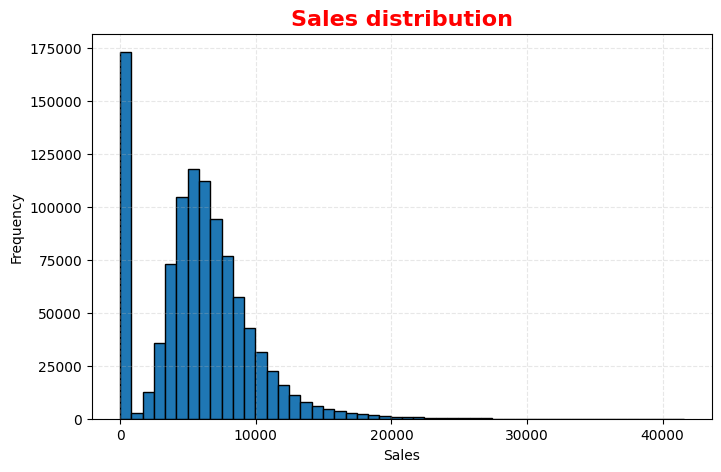

In [53]:
plt.figure(figsize=(8,5))
plt.hist(data['Sales'], bins=50, edgecolor='k')
plt.title("Sales distribution", fontsize=16, fontweight='bold', color = 'red')
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


There are a lot of days that sales = zero what affect Normal distribution and most of machine learning models assume normality so we try to handle it

---
#### Handling Open feature
- All sales while open = 0 (the store closed) sales = 0 it makes sense and this what affects the normal distribution of sales.
- There are some outliers where the store is open, but sales zero it can be data entry error or open for employees closed for customers.
- I can conclude with 100% certainty that if it's closed sales will be zero!
- I found that open column is not statistical significant so I can drop it.

In [54]:
data[data["Open"] == 0]["Sales"].sum()

np.int64(0)

In [55]:
data[data["Open"] == 0].shape[0]

172817

In [56]:
data[(data["Open"] == 1) & (data["Sales"] == 0)].shape[0]

54

In [57]:
data = data[(data.Open == 1) & (data.Sales > 0)]

In [58]:
data.duplicated().sum()

np.int64(0)

Checking the effects of removing closed days

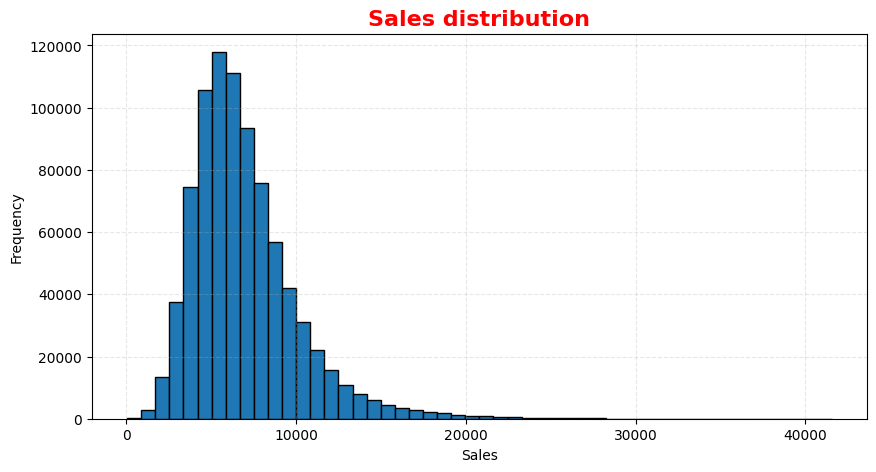

In [59]:
plt.figure(figsize=(10,5))
plt.hist(data['Sales'], bins=50, edgecolor='k')
plt.title("Sales distribution", fontsize=16, fontweight='bold', color = 'red')
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


Data now tends more to apply normal distribution but it still have some outliers 

In [60]:
data["Sales"].quantile(0.99)# 99th percentile of sales is 18k!
## show me the data in the last 1% of sales
data[data["Sales"] > data["Sales"].quantile(0.99)].sort_values("Sales",ascending=False).head(10)

,Store,Open,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
Date_index,,,,,,,,,,,,,,,,,
2015-06-22,909,True,2015-06-22,1,1680.0,NaN,NaN,0,0,False,True,2009.0,45.0,"Feb,May,Aug,Nov",a,c,41551
2015-04-03,262,True,2015-04-03,5,1180.0,5.0,2013.0,b,0,True,False,NaN,NaN,<NA>,b,a,38722
2015-05-01,262,True,2015-05-01,5,1180.0,5.0,2013.0,a,0,True,False,NaN,NaN,<NA>,b,a,38484
2015-05-14,262,True,2015-05-14,4,1180.0,5.0,2013.0,a,1,False,False,NaN,NaN,<NA>,b,a,38367
2014-06-16,57,True,2014-06-16,1,420.0,6.0,2014.0,0,0,True,False,NaN,NaN,<NA>,d,c,38037
2013-12-16,817,True,2013-12-16,1,140.0,3.0,2006.0,0,0,True,False,NaN,NaN,<NA>,a,a,38025
2013-12-16,261,True,2013-12-16,1,15340.0,4.0,2015.0,0,0,True,True,2009.0,39.0,"Jan,Apr,Jul,Oct",d,c,37646
2014-05-29,262,True,2014-05-29,4,1180.0,5.0,2013.0,a,0,False,False,NaN,NaN,<NA>,b,a,37403
2013-12-22,262,True,2013-12-22,7,1180.0,5.0,2013.0,0,0,False,False,NaN,NaN,<NA>,b,a,37376


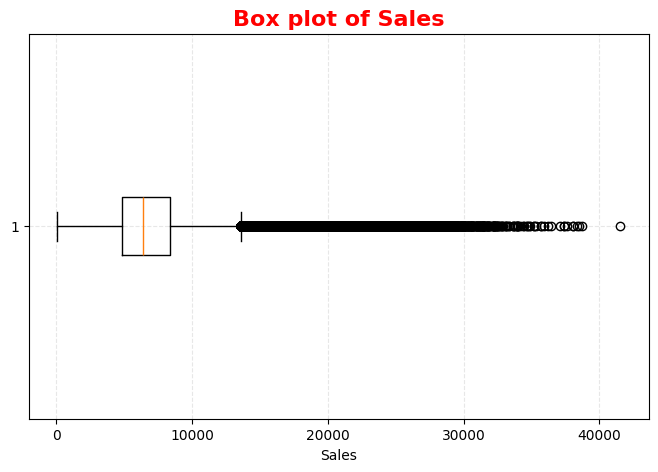

In [61]:
# check outliers in sales using matplot box plot
plt.figure(figsize=(8, 5))
plt.boxplot(data["Sales"], vert=False)
plt.title("Box plot of Sales", fontsize=16, fontweight='bold', c = 'red')
plt.xlabel("Sales")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

n = 844,338, mean = 6955.9591, sd = 3103.8155


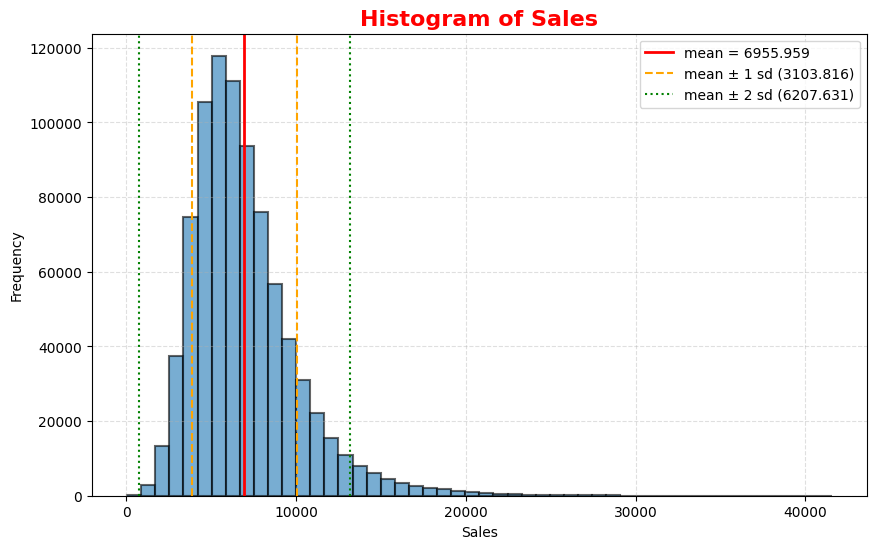

In [62]:
sales = data["Sales"].copy()
label = "Sales"

n = len(sales)
mean = sales.mean()
sd = sales.std(ddof=1)

plt.figure(figsize=(10, 6))
plt.hist(sales, bins=50, color="C0", edgecolor="k", alpha=0.6, density=False, linewidth=1.5)

plt.axvline(mean, color="red", linestyle="-", linewidth=2, label=f"mean = {mean:.3f}")

plt.axvline(
    mean - sd,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"mean ± 1 sd ({sd:.3f})",
)

plt.axvline(mean + sd, color="orange", linestyle="--", linewidth=1.5)

plt.axvline(
    mean - 2 * sd,
    color="green",
    linestyle=":",
    linewidth=1.5,
    label=f"mean ± 2 sd ({2*sd:.3f})",
)

plt.axvline(mean + 2 * sd, color="green", linestyle=":", linewidth=1.5)

plt.title(f"Histogram of {label}", fontsize=16, fontweight="bold", c = 'red')
plt.xlabel(label)
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

print(f"n = {n:,}, mean = {mean:.4f}, sd = {sd:.4f}")

n = 844,338, mean = 8.7576, sd = 0.4253


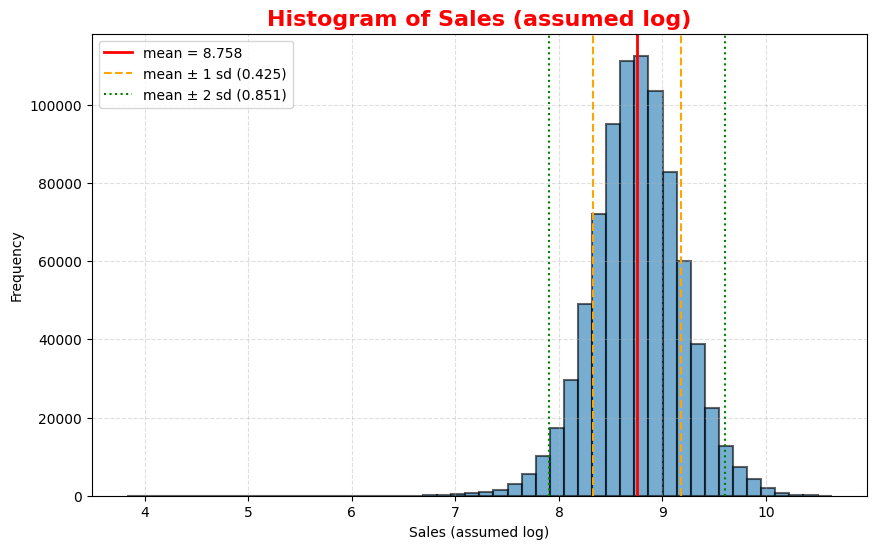

In [63]:
sales = np.log(data['Sales'].copy())
label = "Sales (assumed log)"

n = len(sales)
mean = sales.mean()
sd = sales.std(ddof=1)

plt.figure(figsize=(10, 6))
plt.hist(sales, bins=50, color='C0', edgecolor='k', alpha=0.6, density=False, linewidth=1.5)
plt.axvline(mean, color='red', linestyle='-', linewidth=2, label=f"mean = {mean:.3f}")
plt.axvline(mean - sd, color='orange', linestyle='--', linewidth=1.5, label=f"mean ± 1 sd ({sd:.3f})")
plt.axvline(mean + sd, color='orange', linestyle='--', linewidth=1.5)
plt.axvline(mean - 2*sd, color='green', linestyle=':', linewidth=1.5, label=f"mean ± 2 sd ({2*sd:.3f})")
plt.axvline(mean + 2*sd, color='green', linestyle=':', linewidth=1.5)
plt.title(f"Histogram of {label}", fontsize=16, fontweight='bold', c = 'red')
plt.xlabel(label)
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()

print(f"n = {n:,}, mean = {mean:.4f}, sd = {sd:.4f}")

In [64]:
data['Sales'].quantile([0.0001,0.01, 0.05, 0.1, 0.95, 0.99, 0.99995])

0.00010      762.30110
0.01000     2188.00000
0.05000     3174.00000
0.10000     3762.00000
0.95000    12668.00000
0.99000    17789.00000
0.99995    32797.67545
Name: Sales, dtype: float64

In [65]:
data[data["Sales"] >32000].sort_values(by="Sales", ascending=False)

,Store,Open,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
Date_index,,,,,,,,,,,,,,,,,
2015-06-22,909,True,2015-06-22,1,1680.0,NaN,NaN,0,0,False,True,2009.0,45.0,"Feb,May,Aug,Nov",a,c,41551
2015-04-03,262,True,2015-04-03,5,1180.0,5.0,2013.0,b,0,True,False,NaN,NaN,<NA>,b,a,38722
2015-05-01,262,True,2015-05-01,5,1180.0,5.0,2013.0,a,0,True,False,NaN,NaN,<NA>,b,a,38484
2015-05-14,262,True,2015-05-14,4,1180.0,5.0,2013.0,a,1,False,False,NaN,NaN,<NA>,b,a,38367
2014-06-16,57,True,2014-06-16,1,420.0,6.0,2014.0,0,0,True,False,NaN,NaN,<NA>,d,c,38037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-07-15,106,True,2013-07-15,1,1390.0,8.0,2013.0,0,1,True,False,NaN,NaN,<NA>,a,a,32221
2013-12-16,788,True,2013-12-16,1,1530.0,3.0,2013.0,0,0,True,False,NaN,NaN,<NA>,a,c,32170
2014-12-26,262,True,2014-12-26,5,1180.0,5.0,2013.0,c,1,False,False,NaN,NaN,<NA>,b,a,32169


I Don't know what is better to remove outliers or let it because It has meaning but let us try first without removing and I can return back later.

In [66]:
# print(data.shape[0])
# data_copy = data[(data["Sales"] < data["Sales"].quantile(0.9995)) & (data["Sales"] > data["Sales"].quantile(0.0015)) ]
# print(data.shape[0])

# sales = np.log(data_copy["Sales"].copy())
# label = "Sales (assumed log)"

# n = len(sales)
# mean = sales.mean()
# sd = sales.std(ddof=1)

# plt.figure(figsize=(10, 6))
# plt.hist(
#     sales, bins=50, color="C0", edgecolor="k", alpha=0.6, density=False, linewidth=1.5
# )
# plt.axvline(mean, color="red", linestyle="-", linewidth=2, label=f"mean = {mean:.3f}")
# plt.axvline(
#     mean - sd,
#     color="orange",
#     linestyle="--",
#     linewidth=1.5,
#     label=f"mean ± 1 sd ({sd:.3f})",
# )
# plt.axvline(mean + sd, color="orange", linestyle="--", linewidth=1.5)
# plt.axvline(
#     mean - 2 * sd,
#     color="green",
#     linestyle=":",
#     linewidth=1.5,
#     label=f"mean ± 2 sd ({2*sd:.3f})",
# )
# plt.axvline(mean + 2 * sd, color="green", linestyle=":", linewidth=1.5)
# plt.title(f"Histogram of {label}", fontsize=16, fontweight="bold", c="red")
# plt.xlabel(label)
# plt.ylabel("Frequency")
# plt.grid(True, linestyle="--", alpha=0.4)
# plt.legend()

# print(f"n = {n:,}, mean = {mean:.4f}, sd = {sd:.4f}")

In [67]:
del sales

In [68]:
data['Sales'] = np.log(data['Sales'])

- Now we can say that sales follow normal distribution

In [69]:
data.head()

,Store,Open,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
Date_index,,,,,,,,,,,,,,,,,
2015-07-31,1,True,2015-07-31,5,1270.0,9.0,2008.0,0,1,True,False,NaN,NaN,<NA>,c,a,8.568456
2015-07-31,2,True,2015-07-31,5,570.0,11.0,2007.0,0,1,True,True,2010.0,13.0,"Jan,Apr,Jul,Oct",a,a,8.710125
2015-07-31,3,True,2015-07-31,5,14130.0,12.0,2006.0,0,1,True,True,2011.0,14.0,"Jan,Apr,Jul,Oct",a,a,9.025696
2015-07-31,4,True,2015-07-31,5,620.0,9.0,2009.0,0,1,True,False,NaN,NaN,<NA>,c,c,9.546455
2015-07-31,5,True,2015-07-31,5,29910.0,4.0,2015.0,0,1,True,False,NaN,NaN,<NA>,a,a,8.480944


In [70]:
data.drop(columns="Open",inplace= True)

In [71]:
data.StoreType.value_counts()

StoreType
a    457042
d    258768
c    112968
b     15560
Name: count, dtype: int64

In [72]:
data.Assortment.value_counts()

Assortment
a    444875
c    391254
b      8209
Name: count, dtype: int64

In [73]:
data.StateHoliday.value_counts()

StateHoliday
0    843428
a       694
b       145
c        71
Name: count, dtype: int64

In [74]:
null_counts = data.isna().sum()
na_pct = (null_counts / len(data) * 100).round(2)
na_summary = pd.concat([null_counts, na_pct], axis=1, keys=["count", "percent"])
print(na_summary[na_summary["count"] > 0].sort_values("count", ascending=False))

                            count  percent
Promo2SinceWeek            423292    50.13
Promo2SinceYear            423292    50.13
PromoInterval              423292    50.13
CompetitionOpenSinceMonth  268600    31.81
CompetitionOpenSinceYear   268600    31.81
CompetitionDistance          2186     0.26


In [75]:
data[['Promo', 'Promo2', 'PromoInterval', 'Date', 'Promo2SinceWeek', 'Promo2SinceYear', 'Sales']].head()

,Promo,Promo2,PromoInterval,Date,Promo2SinceWeek,Promo2SinceYear,Sales
Date_index,,,,,,,
2015-07-31,True,False,<NA>,2015-07-31,NaN,NaN,8.568456
2015-07-31,True,True,"Jan,Apr,Jul,Oct",2015-07-31,13.0,2010.0,8.710125
2015-07-31,True,True,"Jan,Apr,Jul,Oct",2015-07-31,14.0,2011.0,9.025696
2015-07-31,True,False,<NA>,2015-07-31,NaN,NaN,9.546455
2015-07-31,True,False,<NA>,2015-07-31,NaN,NaN,8.480944


In [76]:
data[data.Promo2 == False]["PromoInterval"].value_counts()

Series([], Name: count, dtype: Int64)

In [77]:
data[data.Promo2 == False]["Promo2SinceWeek"].nunique()

0

In [78]:
data["PromoInterval"] = data["PromoInterval"].fillna("no_promo")
data["Promo2SinceWeek"] = data["Promo2SinceWeek"].fillna(0)
data["Promo2SinceYear"] = data["Promo2SinceYear"].fillna(0)

In [79]:
data.PromoInterval.isna().sum()

np.int64(0)

In [80]:
data.head()

,Store,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
Date_index,,,,,,,,,,,,,,,,
2015-07-31,1,2015-07-31,5,1270.0,9.0,2008.0,0,1,True,False,0.0,0.0,no_promo,c,a,8.568456
2015-07-31,2,2015-07-31,5,570.0,11.0,2007.0,0,1,True,True,2010.0,13.0,"Jan,Apr,Jul,Oct",a,a,8.710125
2015-07-31,3,2015-07-31,5,14130.0,12.0,2006.0,0,1,True,True,2011.0,14.0,"Jan,Apr,Jul,Oct",a,a,9.025696
2015-07-31,4,2015-07-31,5,620.0,9.0,2009.0,0,1,True,False,0.0,0.0,no_promo,c,c,9.546455
2015-07-31,5,2015-07-31,5,29910.0,4.0,2015.0,0,1,True,False,0.0,0.0,no_promo,a,a,8.480944


In [81]:
data[data['CompetitionOpenSinceMonth'].isna() & data['CompetitionOpenSinceYear'].isna()].head()

,Store,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
Date_index,,,,,,,,,,,,,,,,
2015-07-31,12,2015-07-31,5,1070.0,NaN,NaN,0,1,True,True,2010.0,13.0,"Jan,Apr,Jul,Oct",a,c,9.100414
2015-07-31,13,2015-07-31,5,310.0,NaN,NaN,0,0,True,True,2009.0,45.0,"Feb,May,Aug,Nov",d,a,9.084891
2015-07-31,16,2015-07-31,5,3270.0,NaN,NaN,0,1,True,False,0.0,0.0,no_promo,a,c,9.233178
2015-07-31,19,2015-07-31,5,3240.0,NaN,NaN,0,1,True,True,2011.0,22.0,"Mar,Jun,Sept,Dec",a,c,9.016027
2015-07-31,22,2015-07-31,5,1040.0,NaN,NaN,0,0,True,True,2012.0,22.0,"Jan,Apr,Jul,Oct",a,a,8.789660


In [82]:
data["CompetitionDistanceMissing"] = np.where(data["CompetitionDistance"].isna(), 1, 0)

data['CompetitionDistance'] = data["CompetitionDistance"].fillna(data["CompetitionDistance"].median())

data["CompetitionOpenMissing"] = np.where(data["CompetitionOpenSinceMonth"].isna() | data["CompetitionOpenSinceYear"].isna(), 1, 0)
data['CompetitionOpenSinceYear'] = data["CompetitionOpenSinceYear"].fillna(-1)
data['CompetitionOpenSinceMonth'] = data["CompetitionOpenSinceMonth"].fillna(-1)

In [83]:
data['CompetitionDistanceMissing'] = data['CompetitionDistanceMissing'].astype('bool')
data['CompetitionOpenMissing'] = data['CompetitionOpenMissing'].astype('bool')

In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 2015-07-31 to 2013-01-01
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Store                       844338 non-null  int16         
 1   Date                        844338 non-null  datetime64[ns]
 2   DayOfWeek                   844338 non-null  int8          
 3   CompetitionDistance         844338 non-null  float32       
 4   CompetitionOpenSinceMonth   844338 non-null  float32       
 5   CompetitionOpenSinceYear    844338 non-null  float32       
 6   StateHoliday                844338 non-null  category      
 7   SchoolHoliday               844338 non-null  int8          
 8   Promo                       844338 non-null  bool          
 9   Promo2                      844338 non-null  bool          
 10  Promo2SinceYear             844338 non-null  float32       
 11  Promo2SinceWeek             844

In [85]:
data = data[
    [
        "Store",
        "Date",
        "DayOfWeek",
        "CompetitionDistance",
        "CompetitionOpenSinceMonth",
        "CompetitionOpenSinceYear",
        "CompetitionDistanceMissing",
        "CompetitionOpenMissing",
        "StateHoliday",
        "SchoolHoliday",
        "Promo",
        "Promo2",
        "Promo2SinceYear",
        "Promo2SinceWeek",
        "PromoInterval",
        "StoreType",
        "Assortment",
        "Sales",
    ]
]

In [86]:
data.head()

,Store,Date,DayOfWeek,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,CompetitionDistanceMissing,CompetitionOpenMissing,StateHoliday,SchoolHoliday,Promo,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,StoreType,Assortment,Sales
Date_index,,,,,,,,,,,,,,,,,,
2015-07-31,1,2015-07-31,5,1270.0,9.0,2008.0,False,False,0,1,True,False,0.0,0.0,no_promo,c,a,8.568456
2015-07-31,2,2015-07-31,5,570.0,11.0,2007.0,False,False,0,1,True,True,2010.0,13.0,"Jan,Apr,Jul,Oct",a,a,8.710125
2015-07-31,3,2015-07-31,5,14130.0,12.0,2006.0,False,False,0,1,True,True,2011.0,14.0,"Jan,Apr,Jul,Oct",a,a,9.025696
2015-07-31,4,2015-07-31,5,620.0,9.0,2009.0,False,False,0,1,True,False,0.0,0.0,no_promo,c,c,9.546455
2015-07-31,5,2015-07-31,5,29910.0,4.0,2015.0,False,False,0,1,True,False,0.0,0.0,no_promo,a,a,8.480944


In [87]:
data.shape

(844338, 18)

In [88]:
data.to_parquet("../../Data/Preprocessed/cleaned_training_data_V1.parquet", index=False)